# Buxton Testing

Author: Elias Aoubala

Date: 21/02/2026

In [16]:
import CoolProp.CoolProp as CP

import matplotlib.pyplot as plt

import numpy as np

import handcalcs.render

## 1 - Background

This document contains the authors investigations into the first series of buxton testing that was conducted for the gas-generator.

## 2 - Nitrous Oxide Vapour Pressure

The first batch of testing that was conducted, a reported vapour pressure of 10/15 Bar was evaluated. In this case, the first analysis aims to identify if this was credible or not.

(-40.0, 30.0)

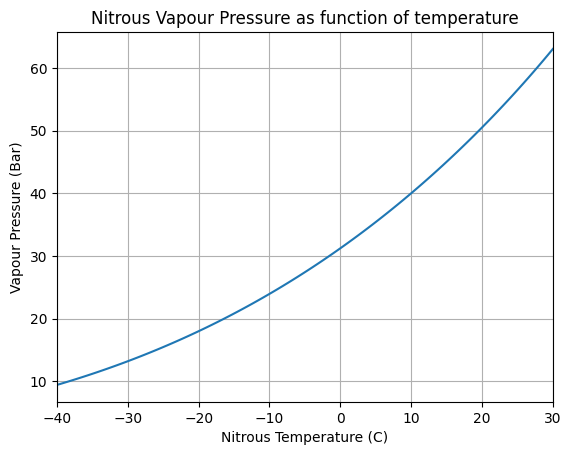

In [9]:
t_array = np.linspace(-40, 30, 100) + 273.15

p_vap_array = np.zeros(100)

for index, val in np.ndenumerate(t_array):
    
    p_vap_array[index] = CP.PropsSI("P", "Q", 1, "T", val, "NitrousOxide")
    
plt.plot(t_array-273.15, p_vap_array/1e5)
plt.xlabel("Nitrous Temperature (C)")
plt.ylabel("Vapour Pressure (Bar)")
plt.title("Nitrous Vapour Pressure as function of temperature")
plt.grid()
plt.xlim([-40,30])


## 3 - Nitrous Oxide Density

(-40.0, 15.0)

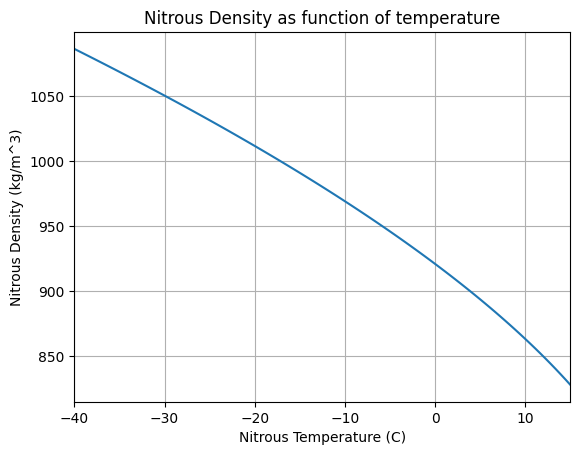

In [15]:
t_array = np.linspace(-40, 15, 100) + 273.15

rho_array = np.zeros(100)

for index, val in np.ndenumerate(t_array):
    
    rho_array[index] = CP.PropsSI("D", "P", 50e5, "T", val, "NitrousOxide")
    
plt.plot(t_array-273.15, rho_array)
plt.xlabel("Nitrous Temperature (C)")
plt.ylabel("Nitrous Density (kg/m^3)")
plt.title("Nitrous Density as function of temperature")
plt.grid()
plt.xlim([-40,15])


We can do a quick derivation to demonstrate how the density variation would impact the mass flow rate. Lets use the normal incompressible flow relation equation for the sake of simplicity.

$$\dot{m} = C_d A \sqrt{2 \rho \Delta P}$$

If we take the same injector (same CdA assumed) and only change the density of the fluid between them, we can derive the following relationship:

$$\dot{m}_1 = C_d A \sqrt{2 \rho_2 \Delta P}$$
$$\dot{m}_2 = C_d A \sqrt{2 \rho_1 \Delta P}$$
$$\frac{\dot{m}_2}{\dot{m}_1} =\frac{C_d A \sqrt{2 \rho_1 \Delta P}}{C_d A \sqrt{2 \rho_2 \Delta P}} $$


Assuming the injector pressures are the same, we get the following:

$$\frac{\dot{m}_2}{\dot{m}_1} =\sqrt{\frac{\rho_1}{\rho_2}} $$

So, the nominal density of the design case was around 786 kg/m^3, we got on the day around 1050 kg/m^3.

From this, we can evaluate for the expected delta in our mass flow rate of Nitrous.

In [18]:
%%render

m_rat =(1050/786)**(1/2)

<IPython.core.display.Latex object>